<a href="https://colab.research.google.com/github/SoniaCamila13/Clasificacion_correos_BERT_USFQ/blob/main/02_modelo_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Primera Prueba de Clasificación con Regresión Logística - técnica de vectorización TF-IDF

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving correos_etiquetados1.csv to correos_etiquetados1.csv


In [ ]:
# Leer archivo (ajusta si es csv o xlsx)
import pandas as pd

df = pd.read_csv("correos_etiquetados1.csv")  # o .xlsx si es Excel
df.head()

,Asunto,Cuerpo,Remitente,Etiqueta
0,Kardex académico,"Buenas tardes, mi nombre es [NOMBRE]\r\n\r\nes...",Andrés Tufiño,certificados
1,Pagos con cheques,Buenas tardes \r\nSoy [NOMBRE] e hice el curso...,Cristhina Sarai Moscoso,Otros trámites
2,Fw: Checks de graduación,\r\n\r\nSent from Outlook for Android <https:/...,José Andrés Chicaiza Salgado,proceso de graduación
3,Problema de inscripcion- [ID],"Buenos días , he intentado varias veces hacer ...",Krupskaya Stefanya Pinzon Cañar,Otros trámites
4,RETIRO DIBUJO MECÁNICO,"Buenos días,\r\n\r\nQuisiera solicitar el reti...",Oscar Esteban León Ñacato,Registro y retiro de materias


In [ ]:
# Unir asunto + cuerpo
df["texto"] = df["Asunto"].fillna("") + " " + df["Cuerpo"].fillna("")

# Variable objetivo
X = df["texto"]
y = df["Etiqueta"]

Accuracy: 0.8480662983425414

Reporte:
                                precision    recall  f1-score   support

               Otros trámites       0.79      0.75      0.77       469
Registro y retiro de materias       0.86      0.88      0.87       587
                 certificados       0.86      0.91      0.89       623
        proceso de graduación       0.95      0.72      0.82       131

                     accuracy                           0.85      1810
                    macro avg       0.87      0.82      0.84      1810
                 weighted avg       0.85      0.85      0.85      1810



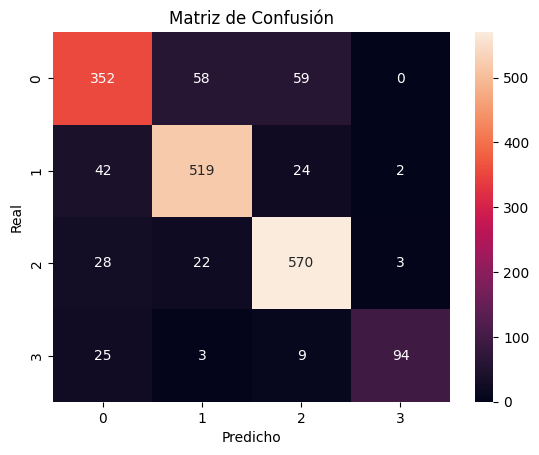

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# División
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vectorización
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Modelo
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

# Predicción
y_pred = model.predict(X_test_vec)

# Métricas
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte:\n", classification_report(y_test, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Matriz de Confusión")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

Conclusiones:


*  Confusión entre categorías con lenguaje similar o ambiguo
*  Dificultad para capturar contexto semántico profundo
*  Dependencia de palabras clave en lugar de comprensión contextual

En particular, el bajo recall en la categoría proceso de graduación sugiere que el modelo no logra identificar todos los casos relevantes, lo que podría impactar negativamente en un entorno real donde estas solicitudes son críticas.